# Lab Tasks - Solutions

In [ ]:
import networkx as nx

## Task 1

The Python dictionary below stores details of Twitter/X follower relations for a set of 6 users on the platform. 

Each key is a username *A* and the corresponding list indicates the names of other users who follow the user *A*.

Based on this data, construct an appropriate network using NetworkX, and identify: 

- The total number of nodes and edges in the network.
- All edges in the network that are *reciprocated*.

In [ ]:
follower_data = {'@alice88': ['@amara2000', '@freya_ie', '@sydney'],
    '@amara2000': ['@freya_ie', '@alice88', '@dobrien', '@marcjones'],
    '@dobrien': ['@marcjones', '@alice88'],
    '@freya_ie': ['@sydney'],
    '@marcjones': ['@freya_ie', '@alice88', '@amara2000', '@dobrien'],
    '@sydney': ['@alice88']}

In [ ]:
# create an empty directed network
g1 = nx.DiGraph()
# process the followers for each user
for username1 in follower_data:
    # add as a node - note that we could skip this step as it will be done automatically 
    # when we add edges
    g1.add_node(username1)
    # add the corresponding directed edges
    # note this should be username1 <- username2, since username2 follows username1
    for username2 in follower_data[username1]:
        g1.add_edge(username2, username1)

In [ ]:
# how many nodes and edges?
print(f"Network has {g1.number_of_nodes()} nodes and {g1.number_of_edges()} edges")

In [ ]:
# check which edges are reciprocated
# there are a few ways to do this
# one way is to check each unique pair of nodes to see if edges exist in both directions
import itertools
for pair in itertools.combinations(follower_data.keys(), r=2):
    # do edges exist in both directions?
    if g1.has_edge(pair[0], pair[1]) and g1.has_edge(pair[1], pair[0]):
        print(pair)

## Task 2

The Python dictionary below records meeting attendances for team members of a research group across an 8 week period. 

Based on this data, construct an appropriate weighted **co-presence** network, and identify: 

- The total number of nodes and edges in the network.
- The edge(s) with the highest weight in the network.

In [ ]:
meeting_data = {'week1': ['bob', 'alice', 'oliver', 'justin'],
    'week2': ['maria', 'tanya', 'justin', 'bob', 'oliver'],
    'week3': ['lara', 'tanya', 'maria', 'justin'],
    'week4': ['justin', 'bob', 'tanya'],
    'week5': ['alice', 'tanya', 'lara', 'bob', 'justin'],
    'week6': ['oliver', 'maria', 'lara'],
    'week7': ['tanya', 'justin', 'bob'],
    'week8': ['maria', 'tanya', 'bob']}

In [ ]:
# create an undirected network
g2 = nx.Graph()
for week in meeting_data:
    # get all unique pairs of individuals from this meeting
    for pair in itertools.combinations(meeting_data[week], r=2):
        # do we have the edge already? if so, increment the weight on the edge
        if g2.has_edge(pair[0], pair[1]):
            g2[pair[0]][pair[1]]["weight"] += 1
        # otherwise create a new edge with a weight of 1
        else:
            g2.add_edge(pair[0], pair[1], weight=1)

In [ ]:
# how many nodes and edges?
print(f"Network has {g2.number_of_nodes()} nodes and {g2.number_of_edges()} edges")

In [ ]:
# iterate over the edges to get the weights
from collections import Counter
weights = Counter()
for node1, node2, data in g2.edges(data=True):
    # create a string from the 2 node names to use as a key
    key = f"{node1}, {node2}"
    weights[key] = data["weight"]
# by using a Python Counter variable, we can easily get the edges with highest weights
weights.most_common()

# Lab Tasks - Solutions

A **collaboration network** in a company captures the relationships between employees who have worked together on the same projects. This type of network analysis is commonly used in organisational studies to understand team dynamics and collaboration patterns.

In this lab we will create this kind of network from an input data file and perform some basic characterisation of the network.

In [2]:
import networkx as nx
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

## Task 1

The file *projects.txt* contains information about the projects undertaken by an IT company. Each line in the file represents a different project and contains the list of employees who worked on that project.

Read in the file *projects.txt*. From this data, create a new **weighted undirected** network that represents the collaborations between employees in the company. Each employee should be represented by a node. An edge should exist between two employees if they have collaborated on at least one project. The weight of each edge should indicate the number of projects on which they have collaborated.

In [3]:
# firstly, read in the data
with open("projects.txt", "r") as fin:
    lines = fin.readlines()

# get the list of employee names for each project
projects = []
for line in lines:
    names = line.strip().split(",")
    projects.append(names)

print(f"Read data for {len(projects)} projects")

Read data for 20 projects


In [4]:
# now create the network
# there are a few different ways to do this
# we could use the itertools.combinations() function to get all pairs for each project
import itertools
g = nx.Graph()
for project in projects:
    # get all unique pairs of employees in this project
    for pair in itertools.combinations(project, r=2):
        # do we have the edge already? if so, increment the weight on the edge
        if g.has_edge(pair[0], pair[1]):
            g[pair[0]][pair[1]]["weight"] += 1
        # otherwise create a new edge with a weight of 1
        else:
            g.add_edge(pair[0], pair[1], weight=1)

## Task 2

From the network created in Task 1, perform the following characterisation:

- How many nodes and edges are in the network?
- Get a list of the nodes in the network
- Create a simple network diagram of the network

In [5]:
# how many nodes and edges?
print(f"Network has {g.number_of_nodes()} nodes and {g.number_of_edges()} edges")

Network has 10 nodes and 31 edges


In [6]:
# get a list of the node identifiers
list(g.nodes())

['Alex',
 'Katie',
 'Rob',
 'Emma',
 'Paul',
 'Mike',
 'Lisa',
 'Mason',
 'David',
 'Sofia']

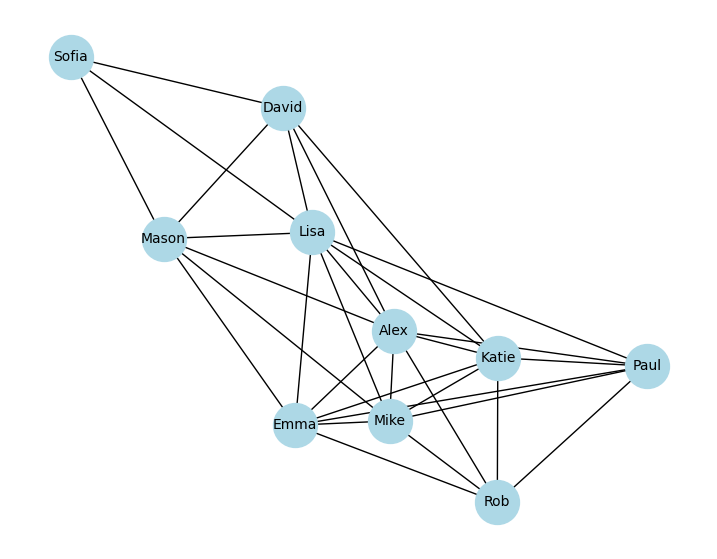

In [7]:
# draw a simple network diagram of the network
plt.figure(figsize=(9, 7))
nx.draw_networkx(g, 
                 with_labels=True, 
                 node_size=1000, 
                 node_color="lightblue", 
                 font_size=10)
plt.axis("off")
plt.show()

## Task 3

Based on the edge weights in the network, perform the following:

- Plot the edge weight distribution for the network.
- Identify the top 5 pairs of employees with the most frequent collaborations (i.e., the highest edge weights).

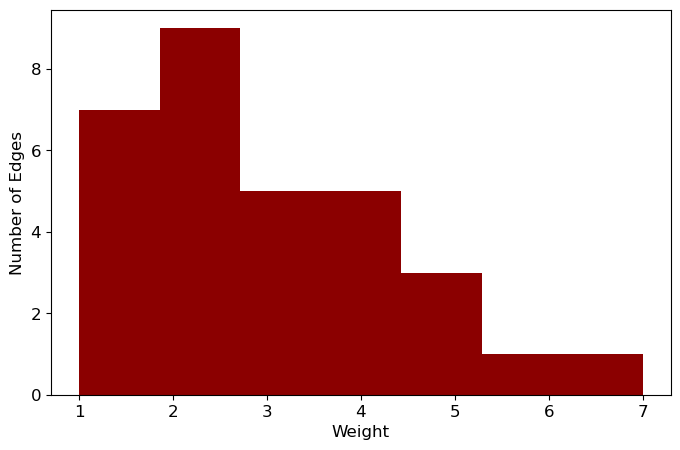

In [8]:
# there are various ways to do this
# one way is to build a dictionary from all the edge weights
weights = {}
for node1, node2, data in g.edges(data=True):
    # create a string from the 2 node names to use as a key
    key = f"{node1}, {node2}"    
    weights[key] = data["weight"]

# convert the dictionary to a Pandas Series for convenience
s_weights = pd.Series(weights)

# plot histogram of edge weight distribution
ax = s_weights.plot.hist(bins=7, figsize=(8, 5), fontsize=12, legend=None, color="darkred")
ax.set_ylabel("Number of Edges", fontsize=12)
ax.set_xlabel("Weight", fontsize=12)
plt.show()

In [9]:
# get the top-5 employee pairs
s_weights.sort_values(ascending=False).head(5)

Alex, Katie    7
Alex, Emma     6
Alex, Lisa     5
Lisa, Mason    5
Katie, Mike    5
dtype: int64

## Task 4

Create a new **unweighted** version of the network by applying **thresholding**, where only edges with weights >= 3 from the original network are preserved (i.e., pairs of employees must have collaborated on at least 3 projects). Exclude nodes which do not have any remaining edges in the new network.

For this new unweighted network:

- How many nodes and edges are in the new network?
- Get a list of the nodes in the network
- Create a simple network diagram of the new network

In [10]:
g2 = nx.Graph()
# iterate over the edges in the original network
for node1, node2, data in g.edges(data=True):
    # apply our edge weight threshold here
    if data["weight"] >= 4:
        g2.add_edge(node1, node2)

In [11]:
# how many nodes and edges in the new network?
print(f"Unweighted network has {g2.number_of_nodes()} nodes and {g2.number_of_edges()} edges")

Unweighted network has 8 nodes and 10 edges


In [12]:
# get a list of the node identifiers in this network
list(g2.nodes())

['Alex', 'Katie', 'Rob', 'Emma', 'Mike', 'Lisa', 'Mason', 'David']

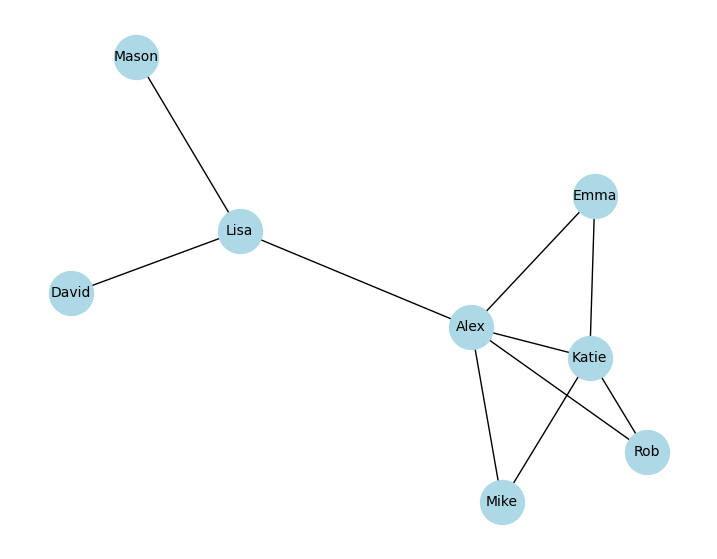

In [13]:
# draw a simple network diagram of the network
plt.figure(figsize=(9, 7))
nx.draw_networkx(g2, 
                 with_labels=True, 
                 node_size=1000, 
                 node_color="lightblue", 
                 font_size=10)
plt.axis("off")
plt.show()

# Lab Tasks - Solutions

In this task, we will look at creating networks from large-scale real-world data.

The dataset used for this task consists of flight records retrieved from the [US Bureau of Transportation Statistics website](https://www.transtats.bts.gov). The data covers the period Q1 and Q2 2016, and includes each flight's origin, destination, along with other relevant metadata. The raw data is provided as a single CSV file (airstats-2016.csv).

In [ ]:
import networkx as nx
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline

### Task 1

Load the flight record data from the file airstats-2016.csv into a Pandas DataFrame, and apply the following filtering steps to the DataFrame:

1. Only include records where the flight origin and destination were both in the United States.
2. Only include records from the time periods Q1 2016 and Q2 2016.
3. Only include records where the reported distance between the origin and destination was at least 20 miles.

In [ ]:
# load the data
df = pd.read_csv("airstats-2016.csv")
print(f"{len(df)} flight records")
df.head()

In [ ]:
# only include records where the flight origin and destination where both in the united states
df2 = df[(df["ORIGIN_COUNTRY"]=="US") & (df["DEST_COUNTRY"]=="US")]
print(f"{len(df2)} flight records after filtering")
df2.head()

In [ ]:
# include only records from the time periods q1 2016 and q2 2016
df3 = df2[(df2["QUARTER"]<3)]
print(f"{len(df3)} flight records after filtering")
df3.head()

In [ ]:
# only include records where the reported distance between the origin and destination was at least 20 miles
df4 = df3[(df3["DISTANCE"]>=20)]
print(f"{len(df4)} flight records after filtering")
df4.head()

### Task 2

Create an **unweighted directed** network from the Pandas DataFrame.

Use the three-letter IATA airport codes for the origin and destination as the node identifiers. Also add the airport's city name as an attribute for each node.

In [ ]:
# get set of all airports
origins = set(df4["ORIGIN"].unique())
destinations = set(df4["DEST"].unique())
airports = origins.union(destinations)

In [ ]:
# create a map from the airport codes to the city name
city_names = {}
for i, row in df4.iterrows():
    city_names[row["ORIGIN"]] = row["ORIGIN_CITY_NAME"]
    city_names[row["DEST"]] = row["DEST_CITY_NAME"]

In [ ]:
# create a directed network and add the nodes
g = nx.DiGraph()
nodes = sorted(list(airports))
for node in nodes:
    g.add_node(node, city=city_names[node])

In [ ]:
# create a directed edge between each unique origin and destination pair, based on the flight records
# note that, in a standard digraph, networkx ignores duplicate edges and only adds them once
for i, row in df4.iterrows():
    node1 = row["ORIGIN"]
    node2 = row["DEST"]
    # ignore self-loops, in case they exist
    if node1 == node2:
        continue
    g.add_edge(node1, node2)

### Task 3

Characterise the unweighted directed network from Task 2, examining:
      
1. How many nodes and edges are in the network?
2. The connectedness of the network (i.e., density and number of components).
3. Identify frequent origin and destination airports in the network (i.e., in-degree and out-degree).
4. Identify key hub airports in the network (i.e., betweenness centrality).

In [ ]:
# how many nodes and edges are in the network?
print(f"Network has {g.number_of_nodes()} nodes and {g.number_of_edges()} edges")

In [ ]:
# what level of density in the network?
nx.density(g)

In [ ]:
# how many strongly connected components?
nx.number_strongly_connected_components(g)

In [ ]:
# create pandas series for in-degree and out-degree scores
s_in = pd.Series(dict(g.in_degree()))
s_out = pd.Series(dict(g.out_degree()))

In [ ]:
# get top ranked by in-degree
s_in.sort_values(ascending=False).head(10)

In [ ]:
# get top ranked by out-degree
s_out.sort_values(ascending=False).head(10)

In [ ]:
# use betweenness centrality to identify key hub airports in the network
s_bet = pd.Series(nx.betweenness_centrality(g))
s_bet.sort_values(ascending=False).head(10)

### Task 4

Now create an alternative **weighted directed** network from the filtered pandas DataFrame.

In [ ]:
# create the new network
g = nx.DiGraph()
nodes = list(airports)
nodes.sort()
for node in nodes:
    g.add_node(node, city=city_names[node])

In [ ]:
# count the flight frequencies between each pair of airports
from collections import Counter
freqs = Counter()
# make sure to apply this to the filtered data frame
for i, row in df4.iterrows():
    node1 = row["ORIGIN"]
    node2 = row["DEST"]
    # ignore self-loops, in case they exist
    if node1 == node2:
        continue
    pair = (node1,node2)
    freqs[pair] += 1

In [ ]:
# now create a directed weighted edge between each unique origin and destination airport pair
for pair in freqs:
    g.add_edge(pair[0], pair[1], weight=freqs[pair])
print(f"Created network with {g.number_of_nodes()} nodes and {g.number_of_edges()} edges")

### Task 5

Based on the weighted directed network, identify:
    
1. The most frequent routes in the network.
2. The most frequent origin and destination airports in the network, considering edge weights.

In [ ]:
# get all the edge weights, so that we can find the highest weight pairs
weights = {}
for e in g.edges(data=True):
    pair = (e[0], e[1])
    weights[pair] = e[2]["weight"]

In [ ]:
# convert to a series
s_weights = pd.Series(weights)
# get the top ranked pairs
s_weights.sort_values(ascending=False).head(10)

In [ ]:
# find the most frequent origin airports, based on weighted out-degree
s_wout = pd.Series(dict(g.out_degree(weight="weight")))
s_wout.sort_values(ascending=False).head(10)

In [ ]:
# find the most frequent destination airports, based on weighted in-degree
s_win = pd.Series(dict(g.in_degree(weight="weight")))
s_win.sort_values(ascending=False).head(10)

# Lab Tasks - Solutions

This task involves working with a dataset which contains information about contacts between patients and health-care workers in a hospital ward in France. The data was gathered using wearable sensors which were able to detect face-to-face close-range proximity between participants wearing the sensors.

For more details see:

- http://www.sociopatterns.org/datasets/hospital-ward-dynamic-contact-network/
- Génois, M., & Barrat, A. Can co-location be used as a proxy for face-to-face contacts?. EPJ Data Science, 7(1), 11. (2018)

The raw data is provided as 2 tab-separated files:

1. *hospital-metadata.csv*: One line per participant in the hospital ward, where each participant has a unique numeric ID and a "status" (e.g., patient, doctor, etc.).
2. *hospital-contacts.csv*: Each line indicates a contact event between two participants, with the time of the event and the numeric IDs of the participants involved.

In [ ]:
import networkx as nx
import pandas as pd

### Task 1

Load the hospital metadata and contact data into two separate Pandas DataFrames.

In [ ]:
# read the metadata
df_metadata = pd.read_csv("hospital-metadata.csv", sep="\t").set_index("participant_id")
df_metadata.head(5)

In [ ]:
# read the contact events
df_contacts = pd.read_csv("hospital-contacts.csv", sep="\t")
df_contacts.head(5)

### Task 2

Create a weighted undirected network from the two DataFrames, such that:

- There is a node for every participant in the study. Each node should have an attribute indicating their "status".
- Edges between nodes have a "weight", indicating the number of times two participants (nodes) have been in contact.

What size is the resulting network?

In [ ]:
# create the undirected network and add the nodes from the metadata
g = nx.Graph()
for participant_id, row in df_metadata.iterrows():
    g.add_node(participant_id, status=row["status"])

In [ ]:
# count frequency of contact between each pair of participants
from collections import Counter
counts = Counter()
for i, row in df_contacts.iterrows():
    node1 = row["participant1"]
    node2 = row["participant2"]
    # represent the pair as a frozen set, so it's unique and hashable
    pair = frozenset([node1, node2])
    counts[pair] += 1

In [ ]:
# add weighted edges for each pair
for p in counts:
    pair = list(p)
    node1, node2 = pair[0], pair[1]
    g.add_edge(node1, node2, weight=counts[p])

In [ ]:
# check size of the network
print(f"Network has {g.number_of_nodes()} nodes and {g.number_of_edges()} edges")

### Task 3

From the network created in Task 2, filter out all isolated nodes (i.e., nodes with degree 0).

In [ ]:
# calculate the degrees by degree
degrees = dict(g.degree())
# figure out which nodes we want to remove
degree_removals = []
for node in degrees:
    if degrees[node] < 1:
        degree_removals.append(node)

In [ ]:
# actually remove the nodes
print(f"Removing: {degree_removals}")
g.remove_nodes_from(degree_removals)
print(f"Filtered network has {g.number_of_nodes()} nodes, {g.number_of_edges()} edges")

### Task 4

Export the filtered network from Task 3 as a new GEXF file.

In [ ]:
# save the filtered network as a GEXF file
nx.write_gexf(g, "hospital.gexf")

### Task 5

Load the GEXF file from Task 4 in Gephi, and complete the following steps:
    
1. Colour the nodes in the network based on their "status" attribute, via the *Appearance Panel* on the *Overview* screen.
2. Calculate the **weighted degree** of the nodes via the *Statistics Panel* on the *Overview* screen.
3. Scale the size of the nodes via the *Appearance Panel* on the *Overview* screen, ranked based on their **weighted degree**.
4. Apply the **Force Atlas** algorithm to lay out the network on the *Overview* screen. Adjust the parameters on the *Layout* panel to improve the network's readability.
5. Filter the nodes in the network to only display nodes with the "status" attribute equal to "doctor", via the *Filters Panel* on the *Overview* screen.
6. Use the *Preview* screen to adjust the final appearance of the network, and then export an image of the network as a PNG file.

In [ ]:
## See hospital.gephi in solutions

# Lab Tasks - Solutions

In this task, we will work with the same dataset from Lab 4, which contains information about contacts between patients and healthcare workers in a hospital ward in France. The data was gathered using wearable sensors that could detect face-to-face close-range proximity of participants wearing the sensors.

The raw data is provided as two tab-separated files:

1. `hospital-metadata.csv`: One line per participant in the hospital ward, where each participant has a unique numeric ID and a "status" (e.g., patient, doctor, etc.).
2. `hospital-contacts.csv`: Each line indicates a contact event between two participants, with the time of the event and the numeric IDs of the participants involved.

In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### Task 1

Load the hospital metadata and contact data into two separate Pandas DataFrames.

In [ ]:
# read the metadata
df_metadata = pd.read_csv("hospital-metadata.csv", sep="\t").set_index("participant_id")
df_metadata.head(5)

In [ ]:
# read the contact events
df_contacts = pd.read_csv("hospital-contacts.csv", sep="\t")
df_contacts.head(5)

### Task 2

Create a weighted undirected network from the two DataFrames, such that:

- There is a node for every participant in the study. Each node should have an attribute indicating their "status".
- Edges between nodes have a "weight", indicating the number of times two participants (nodes) have been in contact.

What size is the resulting network?

In [ ]:
# create the undirected network and add the nodes from the metadata
g = nx.Graph()
for participant_id, row in df_metadata.iterrows():
    g.add_node(participant_id, status=row["status"])

In [ ]:
# count frequency of contact between each pair of participants
from collections import Counter
counts = Counter()
for i, row in df_contacts.iterrows():
    node1 = row["participant1"]
    node2 = row["participant2"]
    # represent the pair as a frozen set, so it's unique and hashable
    pair = frozenset([node1, node2])
    counts[pair] += 1

In [ ]:
# add weighted edges for each pair
for p in counts:
    pair = list(p)
    node1, node2 = pair[0], pair[1]
    g.add_edge(node1, node2, weight=counts[p])

In [ ]:
# check size of the network
print(f"Network: {g.number_of_nodes()} nodes and {g.number_of_edges()} edges")

### Task 3

Using the network created in Task 2, create two different **subgraphs**:

1. The subgraph containing only doctors.
2. The subgraph containing only doctors and patients.

What size are the two resulting subgraphs?

In [ ]:
# find the nodes representing doctors
doctor_nodes = [n for n, attr in g.nodes(data=True) if attr["status"] == "doctor"]
# create a subgraph with the filtered nodes
g_doctors = g.subgraph(doctor_nodes)
# check size of the subgraph
print(f"Doctors subgraph: {g_doctors.number_of_nodes()} nodes and {g_doctors.number_of_edges()} edges")

In [ ]:
# find the nodes representing doctors and patients
doctor_patient_nodes = [n for n, attr in g.nodes(data=True) if attr["status"] in ["doctor", "patient"]]
# create a subgraph with the filtered nodes
g_doctors_patients = g.subgraph(doctor_patient_nodes)
# check size of the subgraph
print(f"Doctors + Patients subgraph: {g_doctors_patients.number_of_nodes()} nodes and {g_doctors_patients.number_of_edges()} edges")

### Task 4

Identify the student with the highest weighted degree score in the overall network. Construct the **ego network** for this node.

Use NetworkX to produce a visualisation of this ego network in your notebook.

In [ ]:
# get list of student nodes
student_nodes = [n for n, attr in g.nodes(data=True) if attr["status"] == "student"]
# calculate the weighted degrees
wdegrees = g.degree(student_nodes, weight="weight")
# convert it to a DataFrame for inspection
wdegree_list = list(wdegrees)
df_wdegree = pd.DataFrame(wdegree_list, columns=["Node", "Degree"]).set_index("Node")
# sort the DataFrame by highest weighted degree
df_wdegree.sort_values(by="Degree", ascending=False, inplace=True)
df_wdegree

In [ ]:
# create the ego network for the student with the highest weight
student_node_id = df_wdegree.index[0]
print(f"Creating ego network for node {student_node_id} ...")
eg = nx.ego_graph(g, student_node_id)
print(f"Ego network: {eg.number_of_nodes()} nodes and {eg.number_of_edges()} edges")

In [ ]:
# visualise the ego network
plt.figure(figsize=(9, 7))
plt.margins(0.1, 0.1)
# position all nodes
pos = nx.spring_layout(eg)
# draw the full network
nx.draw_networkx(eg, pos, with_labels=False, node_size=100, node_color="lightblue")
# draw the ego in red, with larger node size
nx.draw_networkx_nodes(eg, pos, nodelist=[student_node_id], node_size=500, node_color="coral")
plt.axis("off")
plt.show()

### Task 5

Export the ego network from Task 4 as a new GEXF file.

Load the GEXF file in **Gephi** and experiment with different layout algorithms to produce a final visualisation of the ego network.

In [ ]:
# save the ego network as a GEXF file
nx.write_gexf(eg, "ego.gexf")

# Lab Tasks - Solutions

This task involves working with a small network which represents the train routes operated by Irish Rail (http://irishrail.ie). In this type of transport network, each node represents a station, and an edge exists between two nodes if there is a direct route between the corresponding stations.

The dataset is represented via two plain text files:

1. *irish-rail-nodes.txt*: List of stations, each with a unique numeric index (indexed from 0).
2. *irish-rail-adjacency.txt*: Binary adjacency matrix representation for the network.

In [3]:
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Task 1

Load the two dataset files, so that:

1. The index-station name map is represented as a Python dictionary.
2. The adjacency matrix is represented as a NumPy matrix.

In [4]:
# parse the node list file, store it in a dictionary
node_map = {}
fin = open("irish-rail-nodes.txt", "r")
for line in fin.readlines():
    parts = line.strip().split(" ", 1)
    index = int(parts[0])
    station = parts[1]
    # map index -> station name
    node_map[index] = station
fin.close()
print(f"Read index for {len(node_map)} stations")
print(", ".join(sorted(node_map.values())))

Read index for 22 stations
Athenry, Ballina, Belfast, Cobh, Cork, Dublin, Dundalk, Ennis, Galway, Gorey, Limerick, Longford, Mallow, Maynooth, Midleton, Nenagh, Port Laoise, Rosslare, Sligo, Tralee, Waterford, Westport


In [5]:
# load the adjacency matrix
A = np.loadtxt("irish-rail-adjacency.txt", delimiter=",")
print(f"Matrix has {A.shape[0]} rows and {A.shape[1]} columns")

Matrix has 22 rows and 22 columns


## Task 2

From the data structures created in Task 1, create an appropriate NetworkX network to represent the data. Use station names as the node identifiers.

Hint: you can use the function `nx.relabel_nodes()` to re-label the identifiers for all nodes in a network.

From this network, identify:

1. The hub stations in the rail network - i.e. those with the highest degree of connectivity.
2. The peripheral stations in the rail network - i.e. those which are only accessible via a route from **one** other station.

In [6]:
# convert the adjacency matrix into a network
g1 = nx.from_numpy_array(A)
# check the node identifiers in the network
list(g1.nodes())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]

In [2]:
# rename the nodes from numbers to station names
g2 = nx.relabel_nodes(g1, node_map)
# check the node identifiers in the network
list(g2.nodes())

NameError: name 'nx' is not defined

In [ ]:
# calculate the degree for each node
deg = dict(g2.degree())
# convert to a Pandas series
s_deg = pd.Series(deg)

In [ ]:
# get the hubs - i.e. the highest degree nodes
s_deg.sort_values(ascending=False).head()

In [ ]:
# get the peripheral stations in the rail network 
# i.e. the nodes with degree 1
s_deg[s_deg==1]

## Task 3

Visualise the adjacency matrix using a Seaborn heatmap, where the rows and columns are ordered alphabetically by station name.

In [ ]:
# create the alphabetic ordering
nodelist = sorted(node_map.values())
# draw the heatmap using Seaborn
plt.figure(figsize=(14,11))
ax = sns.heatmap(A, linewidths=0.1, xticklabels=nodelist, yticklabels=nodelist)
plt.show()

### Task 4

Export the network from Task 2 as a new GEXF file for further analysis in external tools.

In [ ]:
# save the filtered network as a GEXF file
nx.write_gexf(g2, "irish-rail.gexf")

### Task 5

Load the GEXF file from Task 4 in *Gephi*, and complete the following steps:
    
1. Calculate the **degree** of the nodes using Gephi's statistics panel.
2. Colour and scale the size of the nodes, ranked based on their **degree** values.
3. Test different layout algorithms and parameter values to find a suitable layout for the network structure.
4. Use the *Preview* screen to adjust the final appearance of the network, and then export an image of the network as a PNG file.

In [ ]:
## See irish-rail.gephi in solutions

# Lab Tasks - Solutions

This task involves constructing an ingredient co-occurrence network, often called a **recipe network**, from a dataset of recipes from the website [yummly.com](http://yummly.com) which covers a number of different cuisines, each associated with a specific region. Recipe networks can reveal interesting patterns about how ingredients are combined across different culinary traditions.

In [1]:
from collections import Counter
import json, itertools
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

## Task 1

Load the file *recipes.json*, and then calculate: 
1. The number of recipes per cuisine
2. The total number of unique ingredients
3. The most common ingredients across all recipes

In [2]:
# load the data
fin = open("recipes.json","r")
data = json.load(fin)
fin.close()
print(f"Read {len(data)} recipes")

Read 1048 recipes


In [3]:
# find the number of recipes per cuisine
cuisine_counts = Counter()
for recipe in data:
    cuisine_counts[recipe["cuisine"]] += 1
for cuisine, count in cuisine_counts.most_common():
    print(f"{cuisine}: {count}")

indian: 214
greek: 214
italian: 213
thai: 205
french: 202


In [4]:
# find total number of unique ingredients
all_ingredients = set()
for recipe in data:
    for ingredient in recipe["ingredients"]:
        all_ingredients.add(ingredient)
print(f"Total of {len(all_ingredients)} unique ingredients")

Total of 1544 unique ingredients


In [ ]:
# find the most common ingredients across all recipes
ingredient_counts = Counter()
for recipe in data:
    for ingredient in recipe["ingredients"]:
        ingredient_counts[ingredient] += 1
# display the top 30
rank = 0
for ingredient, count in ingredient_counts.most_common(30):
    rank += 1
    print(f"{rank:02d}. {ingredient}: {count}")

## Task 2

Construct a recipe network from the data, based on the co-occurrence of pairs of ingredients in each recipe. Each node should be an ingredient, and an edge indicates that two ingredients occur at least once in the same recipe. Edge weights indicate the number of times the pair occur together.

Note: When building the network, exclude the following common items from the analysis:

In [ ]:
exclusions = ["water", "salt", "sugar", "butter", "pepper", "black pepper", "oil", "olive oil", "flour"]

In [ ]:
# firstly, count the ingredient pairs in each recipe:
pair_counts = Counter()
for recipe in data:
    # use itertools to find all unique combinations
    recipe_pairs = list( itertools.combinations(recipe["ingredients"], r=2) )
    for ingredient1, ingredient2 in recipe_pairs:
        # exclude this pair?
        if ingredient1 in exclusions or ingredient2 in exclusions:
            continue
        # convert to a set, because the order doesn't matter
        pair = frozenset([ingredient1, ingredient2])
        pair_counts[pair] += 1

In [ ]:
# now create the network from the pair frequencies:
g = nx.Graph()
for pair in pair_counts:
    g.add_edge( *pair, weight=pair_counts[pair] )
g.number_of_nodes(), g.number_of_edges()

## Task 3

Find the top ingredients in the recipe network, based on (i) degree centrality, (ii) weighted degree centrality. These measures will identify the most connected (i.e. important) ingredients in the network.

In [ ]:
# calculate the unweighted degree
degrees = dict(g.degree())
# convert to a Pandas series and sort it
sdeg = pd.Series(degrees, name="degree")
sdeg = sdeg.sort_values(ascending=False)
# display the top 10
pd.DataFrame(sdeg.head(10))

In [ ]:
# calculate the weighted degree
wdegrees = dict(g.degree(weight="weight"))
# convert to a Pandas series and sort it
swdeg = pd.Series(wdegrees, name="w-degree")
swdeg = swdeg.sort_values(ascending=False)
# display the top 10
pd.DataFrame(swdeg.head(10))

## Task 4

Filter the network to remove all edges with weight < 10 (i.e. all pairs of ingredients which have co-occurred in fewer than 10 recipes). This filtering step will focus the analysis on stronger ingredient associations.

Export this filtered network as a GEXF file for use in external network analysis tools.

In [ ]:
# create a new network
g2 = nx.Graph()
for node1, node2, attrs in g.edges(data=True):
    # add the edge?
    if attrs["weight"] >= 10:
        g2.add_edge( node1, node2, **attrs)
g2.number_of_nodes(), g2.number_of_edges()

In [ ]:
# export the filtered network
nx.write_gexf(g2, "recipes-filtered.gexf")

## Task 5

Load the GEXF file from Task 4 in *Gephi*, and complete the following steps:
    
1. Calculate the **degree** of the nodes
2. Colour and scale the size of the nodes, ranked based on their **degree**
3. Test different layout algorithms and parameter values to find a suitable layout for the network
4. Use the *Preview* screen to adjust the final appearance of the recipe network, and then export an image of the network as a PNG file

In [ ]:
# see recipes-filtered.gephi

# Lab Tasks - Solutions

This lab focuses on **community finding** in networks. For the tasks, we will work with a Twitter/X **follower network**. This is a directed network which consists of all follower-followee relationships between a set of users.

Specifically, we will use a dataset collected from the Twitter/X platform, relating to the official user accounts for 30 schools across three Dublin universities. 

The comma-separated file *followers.csv* contains an edge list, where each pair *(A,B)* in the list indicates that user *A* follows user *B*.

In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.float_format', '{:,.3f}'.format)

### Task 1

Load the follower information from the comma-separated file *followers.csv*.

From this data, create a directed **follower network**.

In [ ]:
g = nx.read_edgelist("followers.csv" , delimiter = ",", create_using=nx.DiGraph)
print(f"Network has {g.number_of_nodes()} nodes and {g.number_of_edges()} edges")

### Task 2

Using the network constructed in Task 1, identify the top 10 most influential users in the network based on: (1) in-degree, (2) betweenness centrality.

In [ ]:
in_deg = pd.Series(dict(g.in_degree()), name="in-degree")
pd.DataFrame(in_deg).sort_values(by="in-degree", ascending=False).head(10)

In [ ]:
between = pd.Series(dict(nx.betweenness_centrality(g)), name="betweenness")
pd.DataFrame(between).sort_values(by="betweenness", ascending=False).head(10)

### Task 3

Using the original network from Task 1, construct an **undirected** version of the follower network where an edge *(X,Y)* exists between two users *X* and *Y* if *X* follows *Y* or *Y* follows *X* or both (i.e., the relationships do **not** have to be reciprocal).

In [ ]:
g2 = g.to_undirected(reciprocal=False)
# check the network size
print(f"Number of nodes: {g2.number_of_nodes()}, Number of edges: {g2.number_of_edges()}")

How many components are present in the new network?

In [ ]:
print(f"Number of connected components: {nx.number_connected_components(g2)}")

### Task 4

Apply the Louvain community finding algorithm to the new undirected network.

In [ ]:
# apply the algorithm 
# note we can set a random seed so we get the same results each time
communities_louvain = nx.community.louvain_communities(g2, seed=100)

# get the community sizes (i.e. number of nodes in each community)
for i, c in enumerate(communities_louvain, start=1):
    print(f"Community {i} has {len(c)} nodes")
print()

# display the nodes in each community
for i, c in enumerate(communities_louvain, start=1):
    print(f"Community {i} members:")
    print(c)    
    print()

Produce a visualisation of the network where nodes are coloured based on their community assignment.

Based on the nodes in each community, what does the community structure appear to represent?

In [ ]:
# create a utility function to draw the network with colours defined by community memberships
def draw_communities(g, communities):
    # create a dictionary which maps a node to a community number
    community_map = {}
    for i, community in enumerate(communities):
        for node in community:
            community_map[node] = i
            
    # get an existing colour palette from matplotlib
    pal = plt.get_cmap("Set3")

    # assign colours to the nodes according to the community map
    community_colors = [community_map[node] for node in g.nodes()]

    # draw the network
    plt.figure(figsize=(10,8))
    plt.margins(0.05, 0.05)
    pos = nx.spring_layout(g, seed=55)
    nx.draw(g, pos, 
            with_labels=True, 
            node_color=community_colors, 
            cmap=pal,  
            edge_color="gray", 
            node_size=600,
            font_size=8)
    plt.axis("off")
    plt.show()

# apply the new function to produce a visualisation of the communities
draw_communities(g2, communities_louvain)

# Lab Tasks - Solutions

In this lab, we will explore the analysis of a **dynamic network**, where relationships between nodes change over time. The dataset used for these tasks represents anonymised loan records between users on Prosper, a peer-to-peer lending platform. 

The raw data is stored in CSV format, where each row represents a record indicating who loaned money to whom. Each record includes a numeric timestamp, enabling temporal analysis of lending patterns and network evolution.

In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### Task 1

Load the loan record data from the file *loans.csv* into a Pandas DataFrame. Based on the timestamp data, divide the records into 10 separate time windows of equal duration. Each time window should be represented by a separate DataFrame containing the loan records for that time period.

In [ ]:
# load the data
df = pd.read_csv("loans.csv")
print(f"Read {len(df)} loan records")
df.head(10)

In [ ]:
# check the range of the data
min_time = df["time"].min()
max_time = df["time"].max()
print(f"Time range: {min_time} to {max_time}")

In [ ]:
# based on the timestamp data, divide the records into 10 separate time windows of equal duration:
num_windows = 10
window_size = round((max_time-min_time)/num_windows)
print(f"Window size: {window_size}")

In [ ]:
window_frames = []
current_min = min_time
for window_number in range(1, num_windows+1):
    # set the current window range
    win_min = current_min
    win_max = win_min + window_size
    # handle the last window correctly, so we don't lose data
    if window_number == num_windows:
        wf = df[(df["time"]>=win_min) & (df["time"]<=win_max)]
    else:
        # otherwise we exclude the last day
        wf = df[(df["time"]>=win_min) & (df["time"]<win_max)]
    window_frames.append(wf)
    print(f"Window {window_number:02d}: time {win_min} to {win_max-1} - {len(wf)} interactions")
    # increment
    current_min += window_size

### Task 2

For each time window, construct a corresponding unweighted directed time window network. In these networks, an edge represents a lending relationship, indicating who loaned money to whom during that time period.

In [ ]:
window_networks = []
for w in range(num_windows):
    # NB: this is a directed network
    g = nx.from_pandas_edgelist(window_frames[w], "from_id", "to_id", create_using=nx.DiGraph())  
    print(f"Window {w+1:02d} network has {g.number_of_nodes()} nodes, {g.number_of_edges()} edges")
    window_networks.append(g)

### Task 3

From the time window networks constructed in Task 2, generate time series data for two network characterisation measures:

1. Network density
2. Average node degree

Examine these time series to see if there are any fundamental changes in the dynamic network structure over time. Do the lending patterns exhibit temporal trends or remain relatively stable across the observation period?

In [ ]:
# define a convenience function for plotting a time series using Pandas
def gen_ts_plot(values, measure_name, color):
    s_values = pd.Series(values)
    ax = s_values.plot(figsize=(10, 5), style=".-", ms=12, fontsize=12, color=color, linewidth=2, zorder=3)
    ax.set_xlabel("Time Window", fontsize=12)
    ax.set_ylabel(measure_name, fontsize=12)
    ax.set_title(f"{measure_name} over time", fontsize=12)
    ax.set_xlim((1, len(values)))
    ax.set_ylim((0, s_values.max()*1.1))
    ax.xaxis.grid()
    plt.show()

In [ ]:
# calculate the average degree for each time window network
values = {}
for w in range(num_windows):
    degrees = dict(window_networks[w].degree()).values()
    # get the mean
    values[w+1] = sum(degrees)/len(degrees)
# produce a plot of the values
gen_ts_plot(values, "Average degree", "blue")

In [ ]:
# calculate the density for each time window network
values = {}
for w in range(num_windows):
    values[w+1] = nx.density(window_networks[w])
# produce a plot of the values
gen_ts_plot(values, "Density", "darkred")